# Банковский отток клиентов: логистическая регрессия

**Датасет:** `Bank Customer Churn Prediction.csv`  
**Модель:** Logistic Regression  
**Цель:** предсказать `churn` (1 — клиент ушёл, 0 — остался).

## Шаг 1. Загрузка данных

In [170]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# отображение графиков
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
np.random.seed(42)

# путь к файлу
DATA_PATH = "Bank Customer Churn Prediction.csv"

df = pd.read_csv(DATA_PATH)
print("Данные загружены.")


Данные загружены.


In [171]:
# 1.1. Первые строки
df.head()


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [172]:
# 1.2. Размер датасета
print("Размер датасета:", df.shape)
print(f"Объектов (клиентов): {df.shape[0]}, признаков + target: {df.shape[1]}")


Размер датасета: (10000, 12)
Объектов (клиентов): 10000, признаков + target: 12


In [173]:
# 1.3. Названия колонок
print("Колонки:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


Колонки:
   1. customer_id
   2. credit_score
   3. country
   4. gender
   5. age
   6. tenure
   7. balance
   8. products_number
   9. credit_card
  10. active_member
  11. estimated_salary
  12. churn


In [174]:
# 1.4. Целевая переменная churn
print("Уникальные значения churn:", sorted(df["churn"].unique()))
print("Распределение:")
print(df["churn"].value_counts())
print("\nПроцентное соотношение:")
print(df["churn"].value_counts(normalize=True).round(3))
print("\nВывод: churn — бинарный (0/1). Классы несбалансированы: ушедших ~20%.")


Уникальные значения churn: [np.int64(0), np.int64(1)]
Распределение:
churn
0    7963
1    2037
Name: count, dtype: int64

Процентное соотношение:
churn
0    0.796
1    0.204
Name: proportion, dtype: float64

Вывод: churn — бинарный (0/1). Классы несбалансированы: ушедших ~20%.


## Шаг 2. Первичный анализ данных

Базовая «медкомиссия» таблицы: типы, статистики, пропуски, дубликаты, баланс churn.


In [175]:
# 2.1. Типы данных
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [176]:
# 2.2. Статистика числовых признаков
df.describe().T


,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


In [177]:
# 2.3. Распределение целевой переменной
target_counts = df["churn"].value_counts().sort_index()
print(target_counts)
print(f"\nДоля оттока (churn=1): {df['churn'].mean():.1%}")


churn
0    7963
1    2037
Name: count, dtype: int64

Доля оттока (churn=1): 20.4%


In [178]:
# 2.4. Пропуски
missing = df.isna().sum()
print("Пропуски по столбцам:")
print(missing)

countMissing = int(missing.sum())

if countMissing > 0:
    print("\nВсего пропусков:", int(missing.sum()))
else:
    print("Пропусков нет — заполнять NaN не нужно.")


Пропуски по столбцам:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64
Пропусков нет — заполнять NaN не нужно.


In [179]:
# 2.5. Дубликаты
n_dup_rows = df.duplicated().sum()
n_dup_id = df["customer_id"].duplicated().sum()

if n_dup_rows > 0:
    print("Найдены полностью одинаковые строки. Их количество:", n_dup_rows)
if n_dup_id > 0:
    print("Найдены повторы customer_id. Их количество:", n_dup_id)
if n_dup_rows == 0 and n_dup_id == 0:
    print("Вывод: явных дубликатов нет.")

Вывод: явных дубликатов нет.


## Шаг 3. Разведочный анализ (EDA)

Смотрим визуально: кто уходит чаще, как распределены числа, есть ли связи с `churn`.


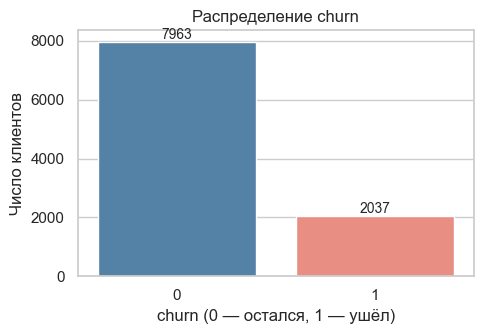

In [180]:
# 3.1. График распределения целевой переменной
fig, ax = plt.subplots(figsize=(5, 3.5))
order = [0, 1]
sns.countplot(data=df, x="churn", order=order, hue="churn", ax=ax, palette=["steelblue", "salmon"], legend=False)
ax.set_title("Распределение churn")
ax.set_xlabel("churn (0 — остался, 1 — ушёл)")
ax.set_ylabel("Число клиентов")
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{int(h)}", (p.get_x() + p.get_width() / 2, h),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


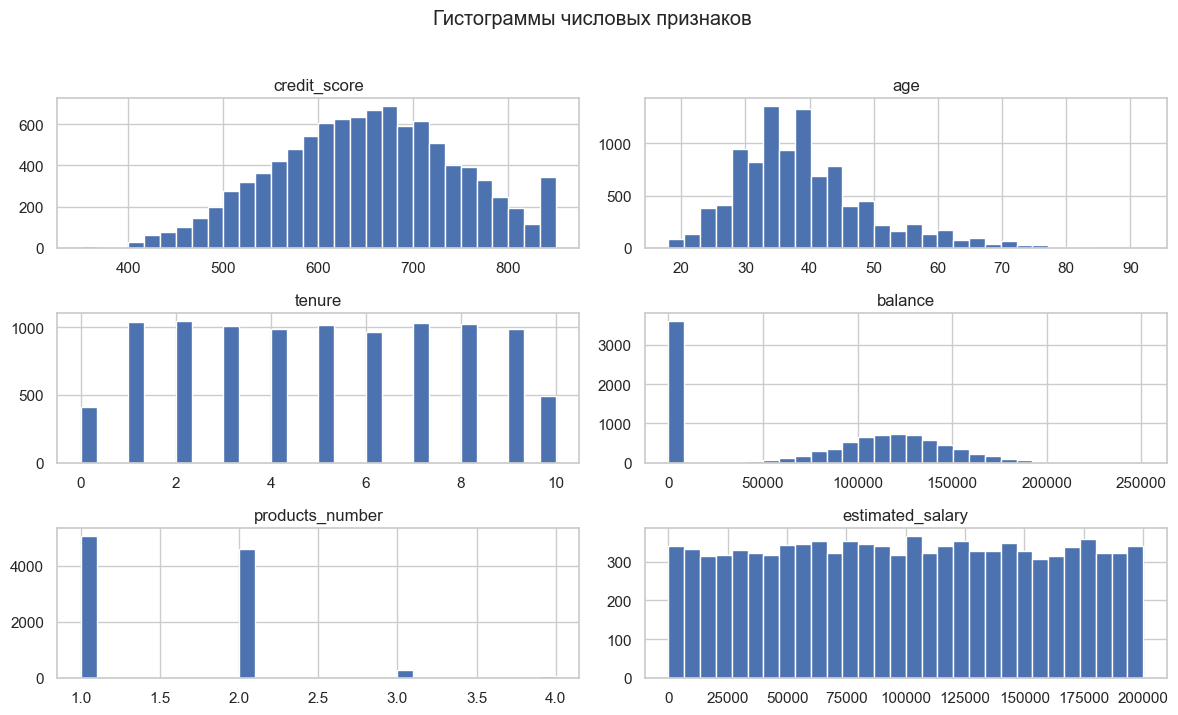

In [181]:
# 3.2. Гистограммы числовых признаков
# X - признак Y - количество клиентов
num_cols = [
    "credit_score", "age", "tenure", "balance",
    "products_number", "estimated_salary",
]
df[num_cols].hist(bins=30, figsize=(12, 7), edgecolor="white")
plt.suptitle("Гистограммы числовых признаков", y=1.02)
plt.tight_layout()
plt.show()


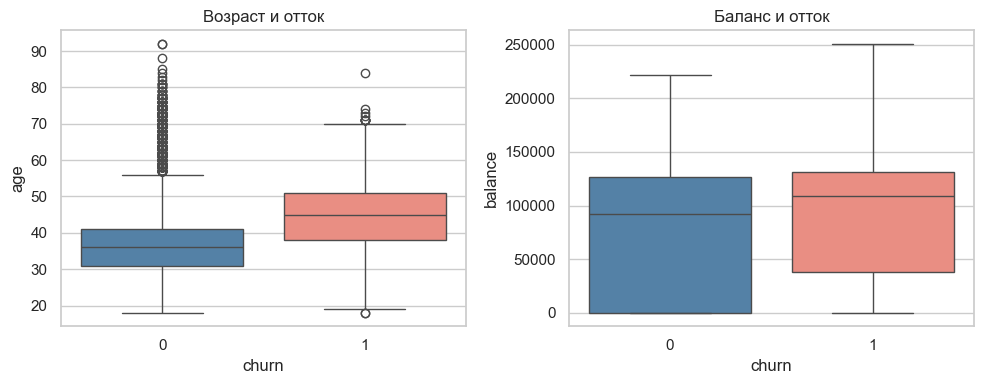

Приблизительное у ушедших (churn=1) медианный возраст выше.
По балансу разница менее однозначная — нет вывода.


In [182]:
# 3.3.* Boxplot: возраст и баланс vs churn
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x="churn", y="age", hue="churn", ax=axes[0], palette=["steelblue", "salmon"], legend=False)
axes[0].set_title("Возраст и отток")
sns.boxplot(data=df, x="churn", y="balance", hue="churn", ax=axes[1], palette=["steelblue", "salmon"], legend=False)
axes[1].set_title("Баланс и отток")
plt.tight_layout()
plt.show()
print("Приблизительное у ушедших (churn=1) медианный возраст выше.")
print("По балансу разница менее однозначная — нет вывода.")


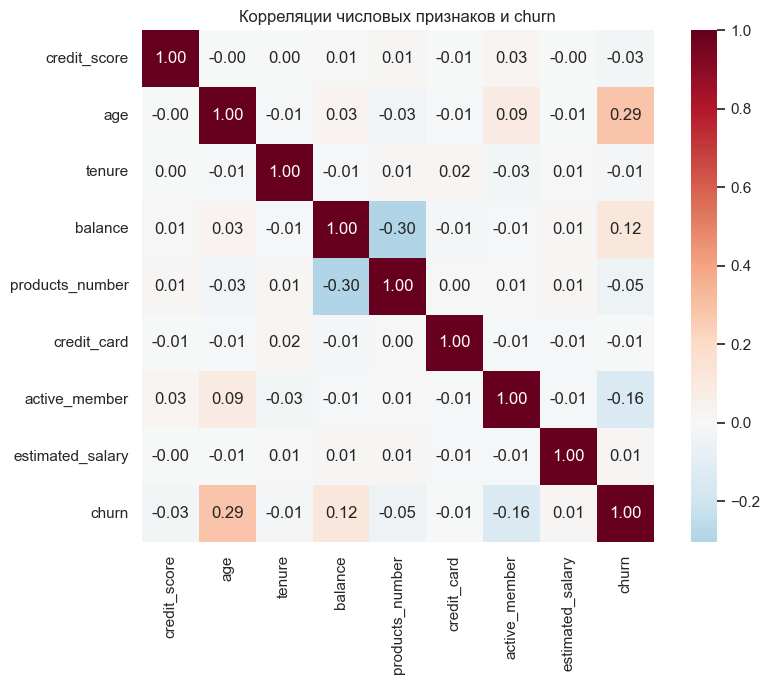

Корреляции с churn (по модулю, убыв.):
age                 0.285
active_member       0.156
balance             0.119
products_number     0.048
credit_score        0.027
tenure              0.014
estimated_salary    0.012
credit_card         0.007
Name: churn, dtype: float64


In [183]:
# 3.4.* Корреляционная матрица (только числа, включая churn)
num_for_corr = [
    "credit_score", "age", "tenure", "balance", "products_number",
    "credit_card", "active_member", "estimated_salary", "churn",
]
corr = df[num_for_corr].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Корреляции числовых признаков и churn")
plt.tight_layout()
plt.show()

print("Корреляции с churn (по модулю, убыв.):")
print(corr["churn"].drop("churn").abs().sort_values(ascending=False).round(3))


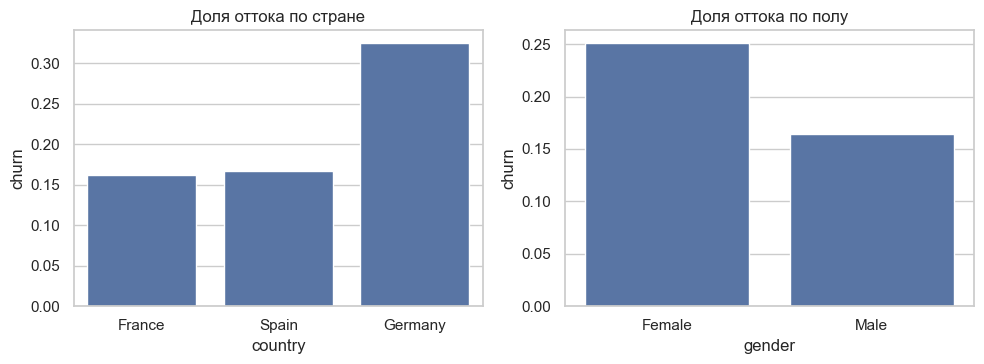

In [184]:
# Дополнительно: отток по стране и полу (категории)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
sns.barplot(data=df, x="country", y="churn", ax=axes[0], errorbar=None)
axes[0].set_title("Доля оттока по стране")
sns.barplot(data=df, x="gender", y="churn", ax=axes[1], errorbar=None)
axes[1].set_title("Доля оттока по полу")
plt.tight_layout()
plt.show()


### Выводы по шагу 3 (EDA)

1. **Дисбаланс классов:** отток ~20%, «остался» ~80%. Accuracy одна может обманывать — смотрим Precision/Recall/F1/ROC-AUC.  
2. **Возраст** заметно связан с оттоком (выше у `churn=1` на boxplot и в корреляции).  
3. **active_member** — отрицательная связь: активные реже уходят.  
4. **balance**, **products_number** — умеренные связи; salary и credit_card — слабые.  
5. По странам/полу доли оттока отличаются (Германия и Female часто выше — уточнится после one-hot и модели).  
6. Пропусков и дубликатов нет — предобработка сводится к кодированию и масштабу.


## Шаг 4. Предобработка данных

Готовим матрицу признаков: убираем лишнее, one-hot для текста, scale для чисел.


In [185]:
# 4.1. Удаление ненужных столбцов
# customer_id — служебный идентификатор, не описывает поведение клиента.
# Если оставить, модель может «запомнить» номер, а не закономерность (и id нельзя обобщать на новых людей).

cols_to_drop = ["customer_id"]
df_model = df.drop(columns=cols_to_drop)
print("Удалили:", cols_to_drop)
print("Остались колонки:", list(df_model.columns))


Удалили: ['customer_id']
Остались колонки: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']


In [186]:
# 4.2–4.4. One-Hot + StandardScaler + итоговый набор
# Разделяем X и y до преобразований
y = df_model["churn"].copy()
X = df_model.drop(columns=["churn"])

cat_features = ["country", "gender"]
num_features = [
    "credit_score", "age", "tenure", "balance",
    "products_number", "credit_card", "active_member", "estimated_salary",
]

print("Категориальные:", cat_features)
print("Числовые:", num_features)

# ColumnTransformer: one-hot для категорий, scale для чисел
# handle_unknown='ignore' — на всякий случай для новых категорий в test
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features),
    ]
)

# Пока только «собираем» preprocessor; fit сделаем на train (шаг 5–6),
# чтобы не было утечки статистик test в scaler.
print("\nPreprocessor готов. fit — только на обучающей выборке (после split).")


Категориальные: ['country', 'gender']
Числовые: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

Preprocessor готов. fit — только на обучающей выборке (после split).


**Почему `drop="first"` у One-Hot?**  
Чтобы убрать идеальную мультиколлинеарность дамми-переменных (для линейных/логистических моделей это полезно).

**Почему scaler только после split?**  
`StandardScaler` запоминает mean/std. Их считают **по train**, иначе test «подглядывает» в расчёт масштаба.


## Шаг 5. Разделение данных

80% — обучение, 20% — честный экзамен. `stratify=y` сохраняет долю оттока в обеих частях.


In [ ]:
# 5. train / test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "доля churn =", round(y_train.mean(), 3))
print("Test: ", X_test.shape, "доля churn =", round(y_test.mean(), 3))


Train: (8000, 10) доля churn = 0.204
Test:  (2000, 10) доля churn = 0.204


## Шаг 6. Обучение модели

Собираем Pipeline: предобработка + `LogisticRegression`. Учим на train, предсказываем на test.


In [188]:
# 6. Pipeline + Logistic Regression
model = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

model.fit(X_train, y_train)

# Предсказания классов и вероятностей класса 1 (для ROC-AUC)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Модель обучена.")
print("Пример предсказаний (первые 15):", y_pred[:15])
print("Пример вероятностей churn (первые 5):", np.round(y_proba[:5], 3))


Модель обучена.
Пример предсказаний (первые 15): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Пример вероятностей churn (первые 5): [0.118 0.279 0.112 0.147 0.095]


## Шаг 7. Оценка качества модели

Считаем метрики на **test**. При дисбалансе смотрим не только Accuracy.


In [189]:
# 7. Метрики
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print("=== Качество на TEST ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall*  : {rec:.4f}")
print(f"F1-score*: {f1:.4f}")
print(f"ROC-AUC* : {roc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["остался (0)", "ушёл (1)"]))


=== Качество на TEST ===
Accuracy : 0.8080
Precision: 0.5891
Recall*  : 0.1867
F1-score*: 0.2836
ROC-AUC* : 0.7748

              precision    recall  f1-score   support

 остался (0)       0.82      0.97      0.89      1593
    ушёл (1)       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



Confusion matrix [[TN FP],[FN TP]]:
[[1540   53]
 [ 331   76]]


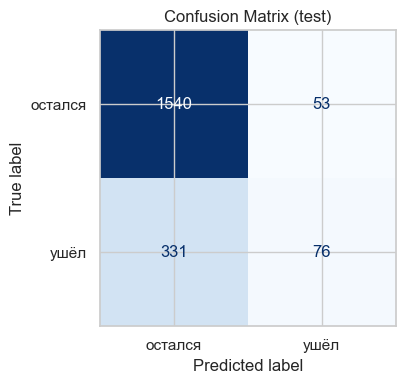

In [190]:
# 7.* Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix [[TN FP],[FN TP]]:")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["остался", "ушёл"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (test)")
plt.tight_layout()
plt.show()


### Вывод по шагу 7

На тестовой выборке (типичный прогон с `random_state=42`):

| Метрика | Значение | Смысл |
|---------|----------|--------|
| Accuracy | ~0.81 | 81% всех ответов верны |
| Precision | ~0.59 | из предсказанных «уйдёт» реально уходит ~59% |
| Recall | ~0.19 | модель ловит лишь ~19% настоящих ушедших |
| F1 | ~0.28 | баланс precision/recall слабый для класса оттока |
| ROC-AUC | ~0.77 | ранжирование клиентов заметно лучше случайного (0.5) |

**Итог:** модель **умеренно** отличает риск оттока (ROC-AUC ≈ 0.77), но при пороге 0.5 **редко** ставит класс «ушёл» → много FN, низкий Recall.  
Для банка, которому важно не пропустить отток, одного Accuracy недостаточно — нужно поднимать Recall (порог, `class_weight`, другая модель).


## Шаг 8. Интерпретация результатов

У логистической регрессии «важность» ≈ **величина коэффициента** (после масштабирования знаки и модули сравнимы).  
Положительный коэффициент → рост признака **повышает** шанс churn; отрицательный — наоборот.


In [191]:
# 8. Важность признаков = |coef_| после prep
clf = model.named_steps["clf"]
prep = model.named_steps["prep"]

# Имена признаков после OneHot + числовые
feature_names = prep.get_feature_names_out()
coefs = clf.coef_.ravel()

imp = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs),
}).sort_values("abs_coefficient", ascending=False)

print("Коэффициенты (по убыванию |coef|):")
print(imp.to_string(index=False))


Коэффициенты (по убыванию |coef|):
              feature  coefficient  abs_coefficient
 cat__country_Germany     0.819952         0.819952
             num__age     0.738520         0.738520
     cat__gender_Male    -0.522198         0.522198
   num__active_member    -0.515739         0.515739
         num__balance     0.161558         0.161558
    num__credit_score    -0.085954         0.085954
 num__products_number    -0.070655         0.070655
num__estimated_salary     0.047797         0.047797
   cat__country_Spain     0.043700         0.043700
     num__credit_card    -0.032120         0.032120
          num__tenure    -0.020063         0.020063


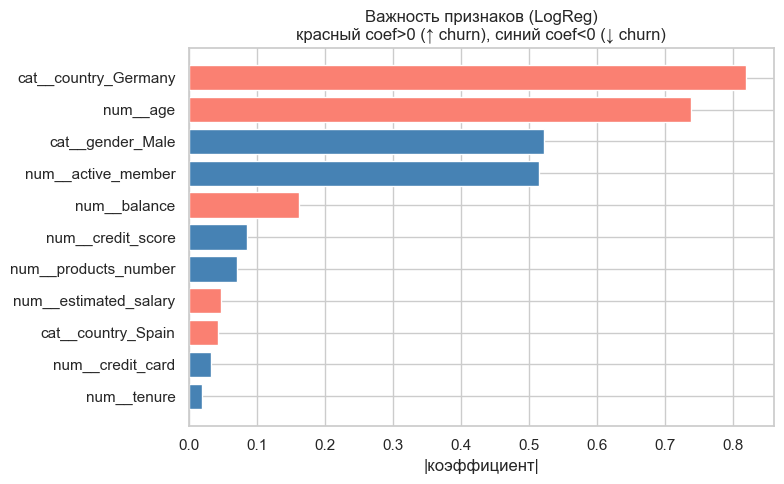

Топ-5 по |коэффициенту|:
             feature  coefficient
cat__country_Germany     0.819952
            num__age     0.738520
    cat__gender_Male    -0.522198
  num__active_member    -0.515739
        num__balance     0.161558


In [192]:
# 8. График важности (горизонтальный bar по |coef|)
plot_df = imp.head(15).sort_values("abs_coefficient")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["salmon" if c > 0 else "steelblue" for c in plot_df["coefficient"]]
ax.barh(plot_df["feature"], plot_df["abs_coefficient"], color=colors)
ax.set_xlabel("|коэффициент|")
ax.set_title("Важность признаков (LogReg)\nкрасный coef>0 (↑ churn), синий coef<0 (↓ churn)")
plt.tight_layout()
plt.show()

print("Топ-5 по |коэффициенту|:")
print(imp.head(5)[["feature", "coefficient"]].to_string(index=False))


### Вывод по шагу 8

По |коэффициентам| (после масштабирования) сильнее всего влияют:

1. **country_Germany** (+) — клиенты из Германии (относительно базовой страны France) имеют выше шанс оттока.  
2. **age** (+) — старше клиент, выше риск ухода.  
3. **gender_Male** (−) — мужчины (относительно Female) реже в оттоке в этой модели.  
4. **active_member** (−) — активные клиенты уходят реже.  
5. **balance** (+) — выше баланс, чуть выше риск (слабее, чем age/страна).

Это согласуется с EDA: возраст и активность уже выделялись на графиках.


## Шаг 9. Итоговые выводы


In [193]:
# 9. Краткая сводка цифр для выводов
print("Размер данных:", df.shape)
print(f"Доля оттока в данных: {df['churn'].mean():.1%}")
print(f"Test Accuracy : {acc:.3f}")
print(f"Test Precision: {prec:.3f}")
print(f"Test Recall   : {rec:.3f}")
print(f"Test F1       : {f1:.3f}")
print(f"Test ROC-AUC  : {roc:.3f}")
print("Топ-3 признака:", ", ".join(imp['feature'].head(3).tolist()))


Размер данных: (10000, 12)
Доля оттока в данных: 20.4%
Test Accuracy : 0.808
Test Precision: 0.589
Test Recall   : 0.187
Test F1       : 0.284
Test ROC-AUC  : 0.775
Топ-3 признака: cat__country_Germany, num__age, cat__gender_Male


### Итоговые выводы (шаг 9)

1. **Насколько хорошо модель предсказывает отток**  
   Logistic Regression — рабочий **baseline**. ROC-AUC ≈ **0.77** значит, модель в целом правильно **ранжирует** риск.  
   Accuracy ≈ **0.81** выглядит неплохо, но при ~20% оттока это частично «успех за счёт класса 0».  
   **Recall ≈ 0.19** — слабое место: большинство реально ушедших **не** помечаются как отток при пороге 0.5.  
   Для задачи удержания клиентов текущая модель скорее **осторожный фильтр**, чем «сеть на всех уходящих».

2. **Какие признаки важнее**  
   - Германия (one-hot), **возраст**, **пол**, **active_member**, **balance**.  
   - Слабо: tenure, credit_card, salary.  
   - `customer_id` правильно исключён: это не поведение, а номер.

3. **\*** Что улучшить  
   - `LogisticRegression(class_weight="balanced")` или другой порог по `predict_proba`.  
   - Подбор `C`, кросс-валидация.  
   - Новые признаки (возрастные группы, balance=0 flag).  
   - Модели сильнее на таблицах: Random Forest, Gradient Boosting.  
   - Отдельный мониторинг Precision/Recall под бизнес-цену FP vs FN.

---

**Чеклист перед сдачей**

- [x] Шаги 1–9 выполнены и пронумерованы  
- [x] Краткие выводы в ноутбуке (EDA, метрики, важность, итог)  
- [x] Код воспроизводим при файле `Bank Customer Churn Prediction.csv` рядом с ноутбуком  
